In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:

df = pd.read_csv(r"C:\\Users\\APURVA\\OneDrive\\文档\\walmart_data.csv")
df.head()


,Order ID,Order Date,Ship Date,Customer Name,Country,City,State,Category,Product Name,Sales,Quantity,Profit
0,CA-2013-138688,6/13/2013,6/17/2013,Darrin Van Huff,United States,Los Angeles,California,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2.0,6.87
1,CA-2011-115812,6/9/2011,6/14/2011,Brosina Hoffman,United States,Los Angeles,California,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.86,7.0,14.17
2,CA-2011-115812,6/9/2011,6/14/2011,Brosina Hoffman,United States,Los Angeles,California,Art,Newell 322,7.28,4.0,1.97
3,CA-2011-115812,6/9/2011,6/14/2011,Brosina Hoffman,United States,Los Angeles,California,Phones,Mitel 5320 IP Phone VoIP phone,907.15,4.0,90.72
4,CA-2011-115812,6/9/2011,6/14/2011,Brosina Hoffman,United States,Los Angeles,California,Binders,DXL Angle-View Binders with Locking Rings by S...,18.50,3.0,5.78


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3203 entries, 0 to 3202
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       3203 non-null   object 
 1   Order Date     3203 non-null   object 
 2   Ship Date      3203 non-null   object 
 3   Customer Name  3203 non-null   object 
 4   Country        3203 non-null   object 
 5   City           3203 non-null   object 
 6   State          3203 non-null   object 
 7   Category       3203 non-null   object 
 8   Product Name   3203 non-null   object 
 9   Sales          3203 non-null   float64
 10  Quantity       3203 non-null   float64
 11  Profit         3203 non-null   float64
dtypes: float64(3), object(9)
memory usage: 300.4+ KB


In [31]:
# === CELL 1: DATA CLEANING ===
import pandas as pd

print("--- Step 1: Loading the Dataset ---")
df = pd.read_csv(r"C:\\Users\\APURVA\\OneDrive\\文档\\walmart_data.csv")
print(f"Data Loaded! Total rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\n--- Step 2: Checking for Missing Values ---")
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found!")

print("\n--- Step 3: Checking & Removing Duplicates ---")
duplicates = df.duplicated().sum()
print(f"Total duplicate rows found: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicate rows have been successfully removed.")

print("\n--- Step 4: Correcting Basic Data Types ---")
# Quantity was loaded as a float (e.g., 2.0), converting it to a clean whole number (Integer)
df['Quantity'] = df['Quantity'].astype(int)
print("Data type for 'Quantity' column updated to Integer.")



--- Step 1: Loading the Dataset ---
Data Loaded! Total rows: 3203, Columns: 12

--- Step 2: Checking for Missing Values ---
Missing values per column:
No missing values found!

--- Step 3: Checking & Removing Duplicates ---
Total duplicate rows found: 0

--- Step 4: Correcting Basic Data Types ---
Data type for 'Quantity' column updated to Integer.


In [32]:
# === CELL 2: DATA PREPROCESSING ===

print("--- Step 5: Converting Date Columns to Datetime Format ---")
# Changing strings to actual datetime objects
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])


--- Step 5: Converting Date Columns to Datetime Format ---


In [33]:
# === CELL 3: FEATURE ENGINEERING ===

print("--- Step 6: Calculating Shipping Days ---")
# Calculating delivery duration: Ship Date minus Order Date
df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days

print("\n--- Step 7: Extracting Time Components from Order Date ---")
# Extracting Year, Month, and the Day Name
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Day of Week'] = df['Order Date'].dt.day_name()

print("4 new columns created: 'Shipping Days', 'Order Year', 'Order Month', 'Order Day of Week'")

print("\n--- Step 8: Saving the Final Cleaned Dataset ---")
output_file = 'walmart_preprocessed_data.csv'
df.to_csv(output_file, index=False)
print(f"[FINAL SUCCESS] Your updated data is saved as '{output_file}'.")

# Take a quick peek at the new features
print("\nNew Features Preview (Top 3 Rows):")
df[['Order ID', 'Shipping Days', 'Order Year', 'Order Month', 'Order Day of Week']].head(3)

--- Step 6: Calculating Shipping Days ---

--- Step 7: Extracting Time Components from Order Date ---
4 new columns created: 'Shipping Days', 'Order Year', 'Order Month', 'Order Day of Week'

--- Step 8: Saving the Final Cleaned Dataset ---
[FINAL SUCCESS] Your updated data is saved as 'walmart_preprocessed_data.csv'.

New Features Preview (Top 3 Rows):


,Order ID,Shipping Days,Order Year,Order Month,Order Day of Week
0,CA-2013-138688,4,2013,6,Thursday
1,CA-2011-115812,5,2011,6,Thursday
2,CA-2011-115812,5,2011,6,Thursday


In [34]:
# === CELL 4: DESCRIPTIVE STATISTICS ===
import pandas as pd

# Load the preprocessed dataset generated from Cell 3
df = pd.read_csv('walmart_preprocessed_data.csv')

print("--- Step 1: Overall Summary Statistics ---")
# Getting mean, median, min, max for key numerical columns
stats_summary = df[['Sales', 'Quantity', 'Profit', 'Shipping Days']].describe()
print(stats_summary)

print("\n--- Step 2: High-Level Insights ---")
avg_sales = df['Sales'].mean()
avg_profit = df['Profit'].mean()
avg_shipping = df['Shipping Days'].mean()

print(f"1. On average, a customer order brings in ${avg_sales:.2f} in Sales.")
print(f"2. The average Profit per order is ${avg_profit:.2f}.")
print(f"3. Orders take an average of {avg_shipping:.1f} days to ship.")
print(f"4. Maximum single-order sale recorded: ${df['Sales'].max():.2f}")
print(f"5. Maximum single-order profit recorded: ${df['Profit'].max():.2f}")

--- Step 1: Overall Summary Statistics ---
              Sales     Quantity       Profit  Shipping Days
count   3203.000000  3203.000000  3203.000000    3203.000000
mean     226.493266     3.828910    33.849138       3.930066
std      524.876911     2.260947   174.109155       1.806914
min        0.990000     1.000000 -3399.980000       0.000000
25%       19.440000     2.000000     3.850000       3.000000
50%       60.840000     3.000000    11.170000       4.000000
75%      215.810000     5.000000    33.000000       5.000000
max    13999.960000    14.000000  6719.980000       7.000000

--- Step 2: High-Level Insights ---
1. On average, a customer order brings in $226.49 in Sales.
2. The average Profit per order is $33.85.
3. Orders take an average of 3.9 days to ship.
4. Maximum single-order sale recorded: $13999.96
5. Maximum single-order profit recorded: $6719.98


--- Step 3: Visualizing Yearly Growth ---


C:\Users\APURVA\AppData\Local\Temp\ipykernel_5820\3253731370.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=yearly_data, x='Order Year', y='Sales', ax=ax[0], palette='Blues_d')


[SUCCESS] Yearly trend chart saved as 'yearly_sales_profit_trend.png'

--- Step 4: Visualizing Monthly Seasonality ---
[SUCCESS] Monthly trend chart saved as 'monthly_seasonality_trend.png'


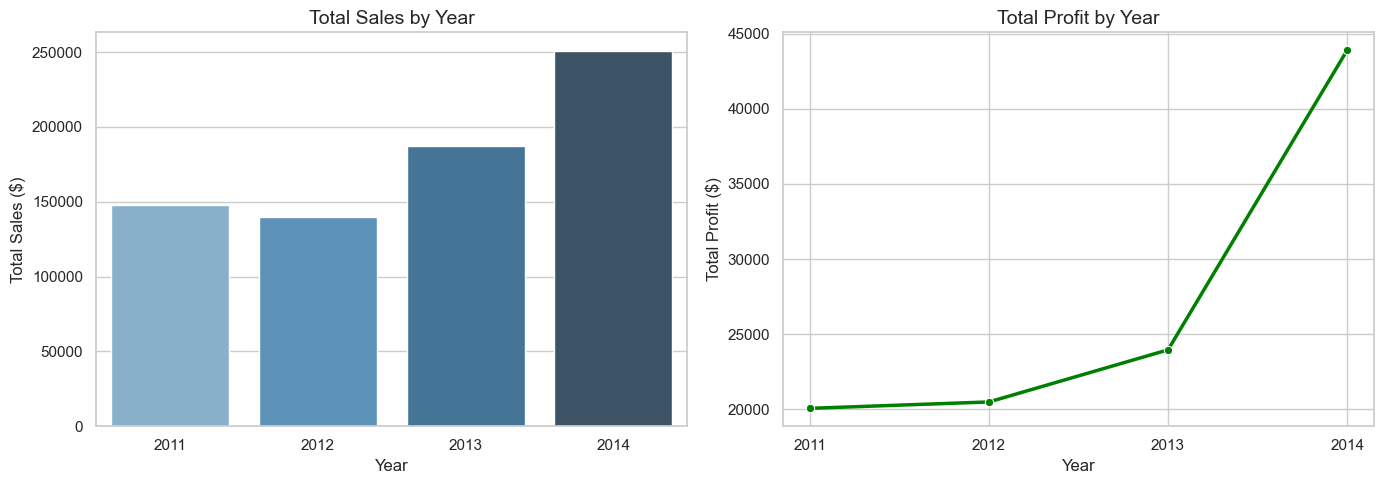

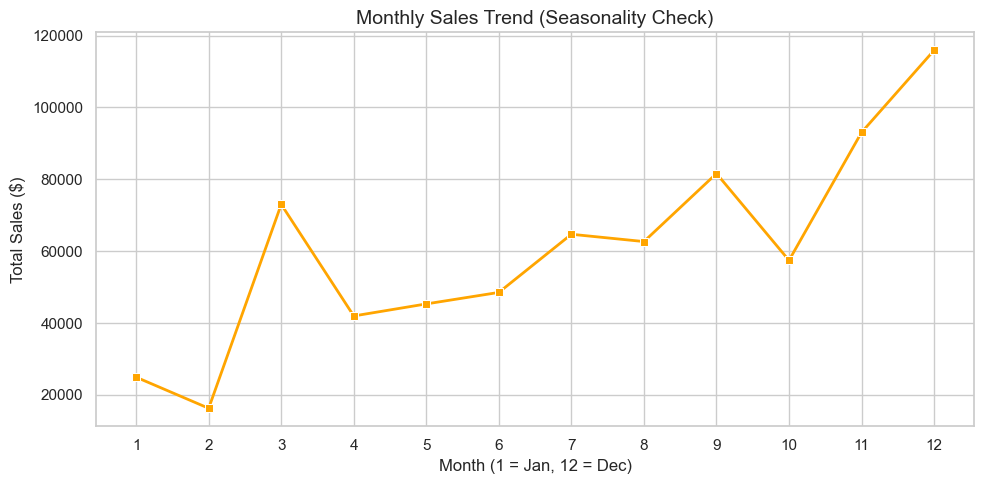

In [35]:
# === CELL 5: TIME-BASED TREND ANALYSIS ===
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean layout style
sns.set_theme(style="whitegrid")

print("--- Step 3: Visualizing Yearly Growth ---")
yearly_data = df.groupby('Order Year')[['Sales', 'Profit']].sum().reset_index()

# Plotting Yearly Sales and Profit side by side
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=yearly_data, x='Order Year', y='Sales', ax=ax[0], palette='Blues_d')
ax[0].set_title('Total Sales by Year', fontsize=14)
ax[0].set_xlabel('Year')
ax[0].set_ylabel('Total Sales ($)')

sns.lineplot(data=yearly_data, x='Order Year', y='Profit', ax=ax[1], marker='o', color='green', linewidth=2.5)
ax[1].set_title('Total Profit by Year', fontsize=14)
ax[1].set_xlabel('Year')
ax[1].set_ylabel('Total Profit ($)')
ax[1].set_xticks(yearly_data['Order Year'])

plt.tight_layout()
plt.savefig('yearly_sales_profit_trend.png', dpi=300)
print("[SUCCESS] Yearly trend chart saved as 'yearly_sales_profit_trend.png'")

print("\n--- Step 4: Visualizing Monthly Seasonality ---")
monthly_sales = df.groupby('Order Month')['Sales'].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly_sales, x='Order Month', y='Sales', marker='s', color='orange', linewidth=2)
plt.title('Monthly Sales Trend (Seasonality Check)', fontsize=14)
plt.xlabel('Month (1 = Jan, 12 = Dec)')
plt.ylabel('Total Sales ($)')
plt.xticks(range(1, 13))

plt.tight_layout()
plt.savefig('monthly_seasonality_trend.png', dpi=300)
print("[SUCCESS] Monthly trend chart saved as 'monthly_seasonality_trend.png'")

--- Step 5: Product Category Performance ---
[SUCCESS] Category performance chart saved as 'category_performance.png'

--- Step 6: Top 5 Cities by Revenue ---
                   Sales    Profit
City                              
Los Angeles    175851.33  30440.94
Seattle        119540.74  29156.13
San Francisco  112669.09  17507.39
San Diego       47521.05   6377.24
Denver          12198.78   -244.91

--- Step 7: Identifying Loss-Making Categories ---
Warning! The following categories are operating at a net LOSS:
    Category     Sales   Profit
7   Machines  42444.14  -618.95
8  Bookcases  36004.18 -1646.50


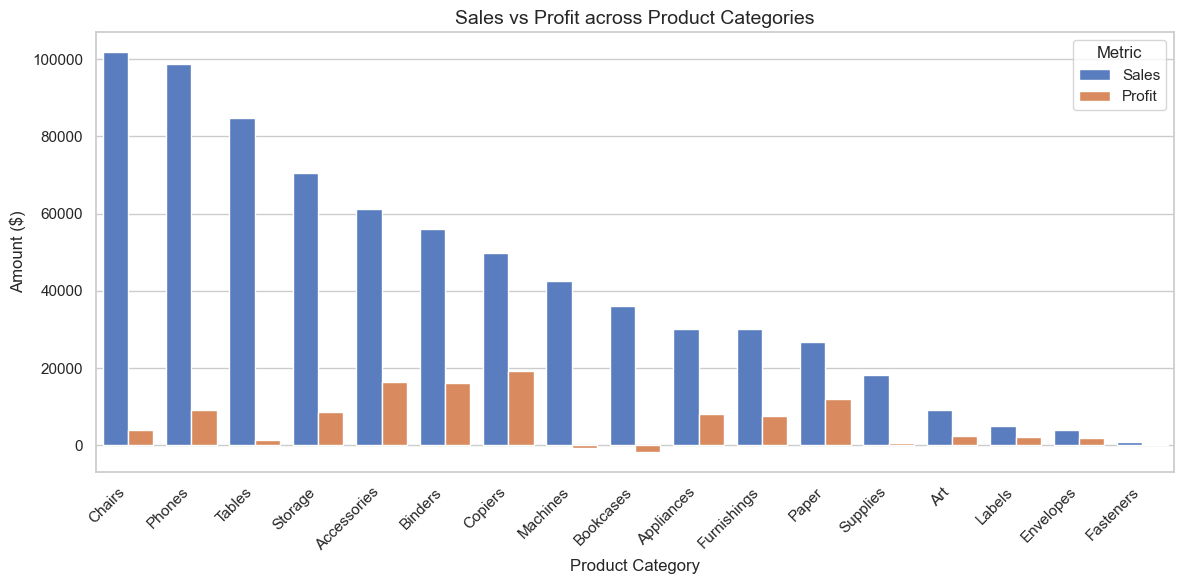

In [36]:
# === CELL 6: CATEGORY & GEOGRAPHY ANALYSIS ===
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Step 5: Product Category Performance ---")
# Grouping by category and sorting by sales
cat_data = df.groupby('Category')[['Sales', 'Profit']].sum().sort_values(by='Sales', ascending=False).reset_index()

plt.figure(figsize=(12, 6))
# Restructuring data for a grouped bar chart
cat_melted = cat_data.melt(id_vars='Category', value_vars=['Sales', 'Profit'], var_name='Metric', value_name='Amount')
sns.barplot(data=cat_melted, x='Category', y='Amount', hue='Metric', palette='muted')
plt.title('Sales vs Profit across Product Categories', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Product Category')
plt.ylabel('Amount ($)')

plt.tight_layout()
plt.savefig('category_performance.png', dpi=300)
print("[SUCCESS] Category performance chart saved as 'category_performance.png'")

print("\n--- Step 6: Top 5 Cities by Revenue ---")
top_cities = df.groupby('City')[['Sales', 'Profit']].sum().sort_values(by='Sales', ascending=False).head(5)
print(top_cities)

print("\n--- Step 7: Identifying Loss-Making Categories ---")
loss_categories = cat_data[cat_data['Profit'] < 0]
if not loss_categories.empty:
    print("Warning! The following categories are operating at a net LOSS:")
    print(loss_categories[['Category', 'Sales', 'Profit']])
else:
    print("Great news! No product categories are running at a net loss.")

In [37]:
pip install psycopg2-binary sqlalchemy

Note: you may need to restart the kernel to use updated packages.


In [38]:
# === CELL 7: UPLOADING CLEANED DATA TO POSTGRESQL ===
import pandas as pd
from sqlalchemy import create_engine

# 1. Load the preprocessed data we created earlier
df = pd.read_csv('walmart_preprocessed_data.csv')

# 2. Configure your PostgreSQL Database credentials
db_config = {
    "user": "postgres",          # Default username postgres hota hai
    "password":1111,  # Apna actual PostgreSQL password yahan likhein
    "host": "localhost",          # Agar aapke laptop par chal raha hai toh localhost
    "port": "5432",              # PostgreSQL ka default port 5432 hota hai
    "database": "walmart_db"     # pgAdmin mein pehle se bani hui database ka naam
}

# 3. Create a SQLAlchemy engine for connection
connection_string = f"postgresql://{db_config['user']}:{db_config['password']}@{db_config['host']}:{db_config['port']}/{db_config['database']}"
engine = create_engine(connection_string)

try:
    print("Connecting to PostgreSQL and creating table...")
    # 4. Push the clean DataFrame into a PostgreSQL table named 'sales_data'
    # if_exists='replace' purani table ko delete karke naye structure ke sath fresh table banata hai
    df.to_sql('sales_data', engine, if_exists='replace', index=False)
    print("[SUCCESS] Python has successfully loaded 'sales_data' into PostgreSQL!")
    
    # Verification Query
    with engine.connect() as connection:
        result = connection.execute("SELECT COUNT(*) FROM sales_data").fetchone()
        print(f"Total rows verified inside PostgreSQL: {result[0]}")

except Exception as e:
    print(f"[ERROR] Connection failed: {e}")
    print("Tip: Make sure you have created 'walmart_db' database inside pgAdmin first!")

Connecting to PostgreSQL and creating table...
[SUCCESS] Python has successfully loaded 'sales_data' into PostgreSQL!
[ERROR] Connection failed: Not an executable object: 'SELECT COUNT(*) FROM sales_data'
Tip: Make sure you have created 'walmart_db' database inside pgAdmin first!


In [39]:
from sqlalchemy import text  # 1. text function ko import karna zaroori hai

try:
    print("Connecting to PostgreSQL and creating table...")
    df.to_sql('sales_data', engine, if_exists='replace', index=False)
    print("[SUCCESS] Python has successfully loaded 'sales_data' into PostgreSQL!")
    
    # 2. Fixed Verification Query using text()
    with engine.connect() as connection:
        result = connection.execute(text("SELECT COUNT(*) FROM sales_data")).fetchone()
        print(f"Total rows verified inside PostgreSQL: {result[0]}")

except Exception as e:
    print(f"[ERROR] Connection failed: {e}")

Connecting to PostgreSQL and creating table...
[SUCCESS] Python has successfully loaded 'sales_data' into PostgreSQL!
Total rows verified inside PostgreSQL: 3203
